Import Library

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score


LOAD DATA

In [19]:
baca = pd.read_csv("go_track_tracks.csv")
baca.head()


,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus,linha
0,1,0,19.210586,0.138049,2.652,3,0,0,1,NaN
1,2,0,30.848229,0.171485,5.290,3,0,0,1,NaN
2,3,1,13.560101,0.067699,0.918,3,0,0,2,NaN
3,4,1,19.766679,0.389544,7.700,3,0,0,2,NaN
4,8,0,25.807401,0.154801,3.995,2,0,0,1,NaN


INFO DATA

In [20]:
baca.info()

<class 'pandas.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              163 non-null    int64  
 1   id_android      163 non-null    int64  
 2   speed           163 non-null    float64
 3   time            163 non-null    float64
 4   distance        163 non-null    float64
 5   rating          163 non-null    int64  
 6   rating_bus      163 non-null    int64  
 7   rating_weather  163 non-null    int64  
 8   car_or_bus      163 non-null    int64  
 9   linha           80 non-null     str    
dtypes: float64(3), int64(6), str(1)
memory usage: 12.9 KB


DROP KOLOM

In [21]:
baca = baca.drop(["linha"], axis=1)
baca.head()


,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus
0,1,0,19.210586,0.138049,2.652,3,0,0,1
1,2,0,30.848229,0.171485,5.290,3,0,0,1
2,3,1,13.560101,0.067699,0.918,3,0,0,2
3,4,1,19.766679,0.389544,7.700,3,0,0,2
4,8,0,25.807401,0.154801,3.995,2,0,0,1


PENENTUAN VARIABEL CLUSTERING

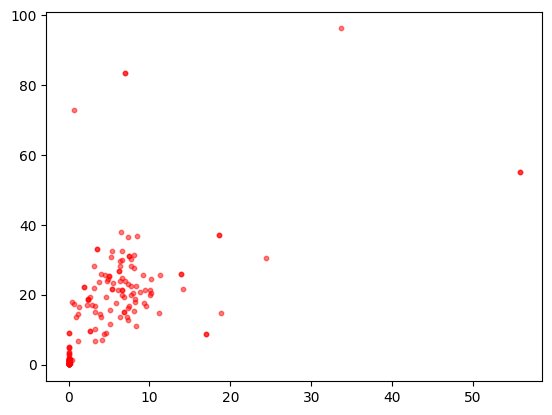

In [22]:
#Menentukan variabel yang akan di klusterkan
baca_x = baca.iloc[:, 1:3]
baca_x.head()

	#Memvisualkan persebaran data
plt.scatter(baca.distance, baca.speed, s =10, c = "red", marker = "o", alpha = 0.5)
plt.show()


UBAH DATA FRAME JADI ARRAY

In [23]:
x_array = np.array(baca_x)
print(x_array)


[[0.00000000e+00 1.92105856e+01]
 [0.00000000e+00 3.08482291e+01]
 [1.00000000e+00 1.35601009e+01]
 [1.00000000e+00 1.97666790e+01]
 [0.00000000e+00 2.58074009e+01]
 [2.00000000e+00 1.34691332e+00]
 [3.00000000e+00 3.68507874e+01]
 [1.00000000e+00 1.74051313e+01]
 [1.00000000e+00 1.53954361e+01]
 [1.00000000e+00 8.90272944e+00]
 [3.00000000e+00 1.50413480e+01]
 [3.00000000e+00 1.44400981e+01]
 [1.00000000e+00 1.63567325e+01]
 [1.00000000e+00 1.75427999e+01]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 1.62635039e+01]
 [4.00000000e+00 2.12235944e+01]
 [4.00000000e+00 1.94236545e+01]
 [4.00000000e+00 2.07996291e+01]
 [4.00000000e+00 8.72437242e+00]
 [4.00000000e+00 8.72437242e+00]
 [3.00000000e+00 8.68613764e+00]
 [3.00000000e+00 5.49959473e+01]
 [3.00000000e+00 5.49959473e+01]
 [1.00000000e+00 1.26110448e+01]
 [3.00000000e+00 1.45342872e+01]
 [3.00000000e+00 1.02882267e+01]
 [3.00000000e+00 1.83281891e+01]
 [1.00000000e+00 1.71776350e+01]
 [1.000000

normalisasi data menggunakan metode Min-Max Scaling

In [24]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)
x_scaled


array([[0.00000000e+00, 1.99600362e-01],
       [0.00000000e+00, 3.20578504e-01],
       [3.70370370e-02, 1.40861225e-01],
       [3.70370370e-02, 2.05381184e-01],
       [0.00000000e+00, 2.68176999e-01],
       [7.40740741e-02, 1.39000630e-02],
       [1.11111111e-01, 3.82977592e-01],
       [3.70370370e-02, 1.80831914e-01],
       [3.70370370e-02, 1.59940297e-01],
       [3.70370370e-02, 9.24459124e-02],
       [1.11111111e-01, 1.56259404e-01],
       [1.11111111e-01, 1.50009162e-01],
       [3.70370370e-02, 1.69933373e-01],
       [3.70370370e-02, 1.82263037e-01],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 1.68964223e-01],
       [1.48148148e-01, 2.20526426e-01],
       [1.48148148e-01, 2.01815302e-01],
       [1.48148148e-01, 2.16119130e-01],
       [1.48148148e-01, 9.05918170e-02],
       [1.48148148e-01, 9.05918170e-02],
       [1.11111111e-01, 9.01943506e-02],
       [1.11111111e-01, 5.71604072e-01],
       [1.111111

MODEL KLASIFIKASI

In [25]:
from sklearn.cluster import KMeans

# Membuat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Training model
kmeans.fit(baca)

# Menampilkan label cluster
print(kmeans.labels_)

# Menambahkan hasil cluster ke dataframe
baca["kluster"] = kmeans.labels_

# Menampilkan data
print(baca.head())


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
   id  id_android      speed      time  distance  rating  rating_bus  \
0   1           0  19.210586  0.138049     2.652       3           0   
1   2           0  30.848229  0.171485     5.290       3           0   
2   3           1  13.560101  0.067699     0.918       3           0   
3   4           1  19.766679  0.389544     7.700       3           0   
4   8           0  25.807401  0.154801     3.995       2           0   

   rating_weather  car_or_bus  kluster  
0               0           1        0  
1               0           1        0  
2               0           2        0  
3               0           2        0  
4               0           1 

In [ ]:
from sklearn.metrics import silhouette_score

# Menggunakan data awal (baca_x atau x_scaled) dan label hasil clusterinng.
score = silhouette_score(x_scaled, kmeans.labels_)
print(f"Silhouette Score: {score}")

Silhouette Score: -0.09844677540915989


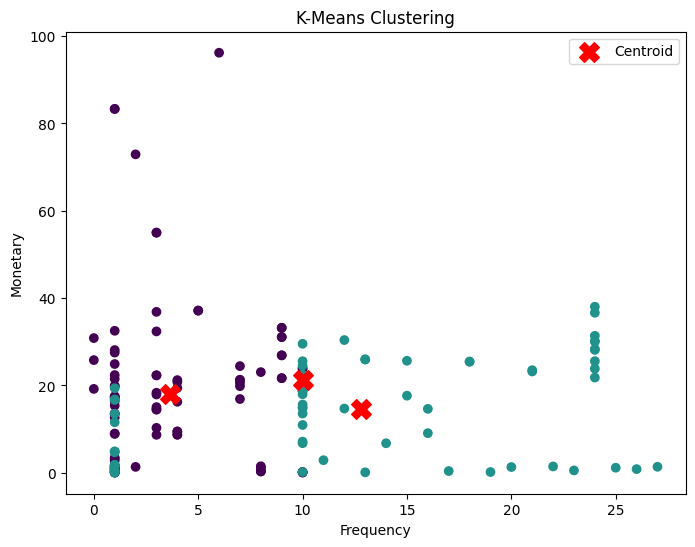

In [ ]:
import matplotlib.pyplot as plt

# Plot hasil clustering
plt.figure(figsize=(8,6))

plt.scatter(
    baca['id_android'],
    baca['speed'],
    c=baca['kluster'],
    cmap='viridis'
)

# Titik centroid
plt.scatter(
    kmeans.cluster_centers_[:, 1],   # Frequency
    kmeans.cluster_centers_[:, 2],   # Monetary
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('K-Means Clustering')
plt.legend()

plt.show()
